# Solar-climate connections over the Common Era 

## Authors

Julien Emile-Geay [![ORCID](https://img.shields.io/badge/ORCID-0000--0001--5920--4751-A6CE39?logo=orcid)](https://orcid.org/0000-0001-5920-4751), Feng Zhu [![ORCID](https://img.shields.io/badge/ORCID-0000--0002--9969--2953-A6CE39?logo=orcid)](https://orcid.org/0000-0002-9969-2953) and Deborah Khider [![ORCID](https://img.shields.io/badge/ORCID-0000--0001--7501--8430-A6CE39?logo=orcid)](https://orcid.org/0000-0001-7501-8430)


## Preamble

Variations in solar irradiance have been hypothesized to be responsible for part of the variability in global mean surface temperature (GMST) over the Common Era (the last 2,000 years or so). In this notebook we use [Pyleoclim](https://pyleoclim-util.readthedocs.io/en/latest/) to test this hypothesis using wavelet transform coherency between reconstructions of solar irradiance and GMST.

This notebook reproduces [Fig S16](https://static-content.springer.com/esm/art%3A10.1038%2Fs41561-019-0400-0/MediaObjects/41561_2019_400_MOESM1_ESM.pdf) of [PAGES2k Consortium (2019)](https://doi.org/10.1038/s41561-019-0400-0) and adds an analysis of phase statistics. 

Technical Skills Involved:
* Loading data using [pandas](https://pandas.pydata.org)
* Applying and interpreting [Wavelet Transform Coherency](https://pyleoclim-util.readthedocs.io/en/latest/core/api.html#pyleoclim.core.series.Series.wavelet_coherence) analysis
* Quantifying phase relationships using [phase statistics](https://pyleoclim-util.readthedocs.io/en/latest/core/api.html#pyleoclim.core.coherences.Coherence.phase_stats) (circular standard deviation and Von Mises concentration)


### Data

- Reconstruction of solar irradiance:SATIRE-H dataset ([Vieira et al. (2011)](https://doi.org/10.1051/0004-6361/201015843)), as compiled by [Barboza et al. (2019)](https://doi.org/10.1007/s13253-019-00372-4). 
- Global mean surface temperature: Ensemble of [PAGES2k Consortium (2019)](https://doi.org/10.1038/s41561-019-0400-0), who applied 7 different statistical methods to the [PAGES 2k version 2 temperature database](https://doi.org/10.1038/sdata.2017.88). 

### Reading time
5 min

### Keyword
Pyleoclim; Coherence Analyis; Common Era; Solar irradiance

Let's load the necessary packages:

In [1]:
# load packages
import pyleoclim as pyleo
import pandas as pd
import numpy as np
import os
from matplotlib import gridspec
import matplotlib.pyplot as plt
from tqdm import tqdm

## Exploratory Data Analysis

Let's start by opening the forcing data and GMST reconstruction:

In [2]:
database_path = '../data/'
forcing_filename = 'Neukom2019_forcing.csv'
GMST_filename = 'Neukom2019_GMST_recon_medians_selection.txt'

forcing_df = pd.read_csv(os.path.join(database_path, forcing_filename)) 
GMST_df = pd.read_table(os.path.join(database_path, GMST_filename))

In [3]:
display(GMST_df.head())

,Year,CPS_R-FDR_longcalib,PCR_R-FDR_longcalib,M08_R-FDR_longcalib,PAI_R-FDR_longcalib,OIE_R-FDR_longcalib,BHM_R-FDR_longcalib,LMR_R-FDR_longcalib
0,1,-0.3298,-0.3844,-0.1543,-0.4421,-0.2994,-0.3913,-0.1115
1,2,-0.2933,-0.3744,-0.1962,-0.3966,-0.2530,-0.4667,-0.1084
2,3,-0.2343,-0.3384,-0.2287,-0.2909,-0.1520,-0.4396,-0.1017
3,4,-0.2238,-0.3179,-0.2779,-0.2047,-0.1795,-0.3895,-0.0703
4,5,-0.2823,-0.3474,-0.2609,-0.2533,-0.1047,-0.2997,-0.0910


In [4]:
display(forcing_df.head())

,CO2,volcanic,solar
0,277.45,0.004314,1365.551796
1,277.14,0.004312,1365.544193
2,277.16,0.004312,1365.537762
3,277.16,0.010717,1365.532407
4,277.16,0.009114,1365.528030


Let's import this information into Pyleoclim and plot the corresponding timeseries: 

In [5]:
ts_solar = pyleo.Series(time=GMST_df['Year'].values, 
                        value=forcing_df['solar'].values, 
                        label='Total Solar Irradiance', 
                        time_name='Year', 
                        time_unit='CE', 
                        value_name='TSI', 
                        value_unit=r'W m$^{-2}$')


Time axis values sorted in ascending order


In [6]:
exp_names = list(GMST_df.columns.values)[1:]

ts = {}
for i, exp in enumerate(exp_names):
    ts[exp] = pyleo.Series(time=GMST_df['Year'].values, 
                           value=GMST_df[exp].values, 
                           label=exp, 
                           time_name='Year', 
                           time_unit='CE', 
                           value_name='T anomaly', 
                           value_unit='K')

Time axis values sorted in ascending order
Time axis values sorted in ascending order
Time axis values sorted in ascending order
Time axis values sorted in ascending order
Time axis values sorted in ascending order
Time axis values sorted in ascending order
Time axis values sorted in ascending order


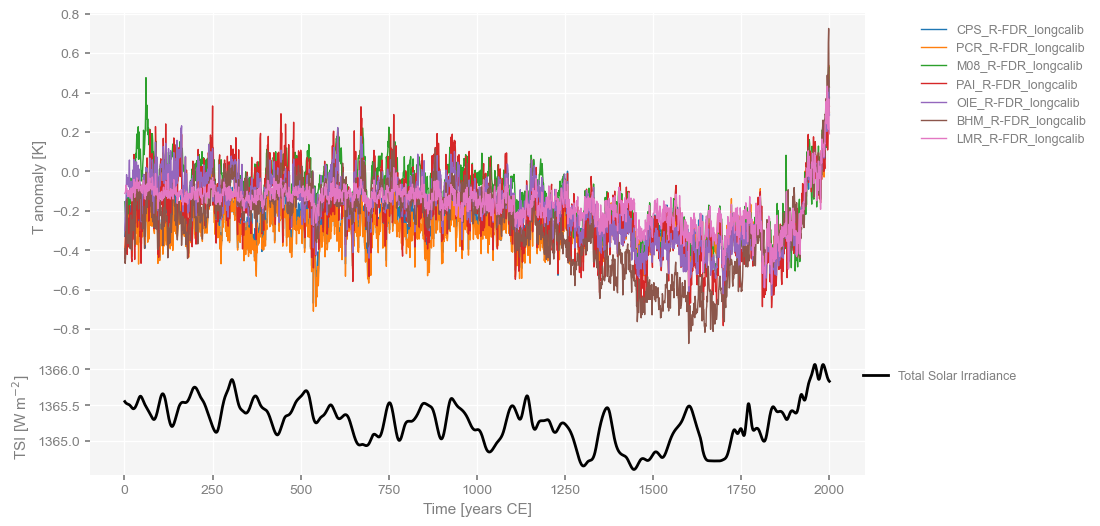

In [7]:
pyleo.set_style('web')
gs = gridspec.GridSpec(4, 1)
gs.update(wspace=0, hspace=0)

fig = plt.figure(figsize=[10, 6])
ax1 = plt.subplot(gs[0:3, :])
for i, exp in enumerate(exp_names):
    ts[exp].plot(ax=ax1,linewidth=1)
ax1.legend(bbox_to_anchor=(1.3, 1.0), loc='upper right')
    
ax2 = plt.subplot(gs[3, :], sharex=ax1)
ts_solar.plot(ax=ax2, linewidth=2, color='black')    
ax2.legend(bbox_to_anchor=(1.21, 1.0), loc='upper right')

## Wavelet coherency analysis

This uses Pyleoclim's [wavelet coherence method](https://pyleoclim-util.readthedocs.io/en/latest/core/api.html#pyleoclim.core.series.Series.wavelet_coherence). Since the series are evenly-spaced, we will use the [CWT](https://pyleoclim-util.readthedocs.io/en/latest/utils/introduction.html?highlight=cwt#pyleoclim.utils.wavelet.cwt_coherence) method.

In [8]:
scale = np.logspace(1, 11, num=51, base=2)
freq = 1/scale[::-1]
coh = {}
for exp in tqdm(exp_names):
    print('Evaluating coherence with '+ exp +'\n')
    coh[exp] = ts_solar.wavelet_coherence(ts[exp], 
                settings={'freq':freq}).signif_test(number=200, mute_pbar=True)

  0%|          | 0/7 [00:00<?, ?it/s]

Evaluating coherence with CPS_R-FDR_longcalib



 14%|█▍        | 1/7 [00:06<00:41,  6.95s/it]

Evaluating coherence with PCR_R-FDR_longcalib



 29%|██▊       | 2/7 [00:14<00:35,  7.04s/it]

...

 71%|███████▏  | 5/7 [00:35<00:14,  7.19s/it]

Evaluating coherence with BHM_R-FDR_longcalib



 86%|████████▌ | 6/7 [00:43<00:07,  7.25s/it]

Evaluating coherence with LMR_R-FDR_longcalib



100%|██████████| 7/7 [00:50<00:00,  7.21s/it]


We can now plot the results for each reconstruction. cohors indicate the level of coherency, while arrows show the phase angle (right = 0°, left = 180°, top = 90°, bottom = 270°, with intermediate directions representing angles in between).

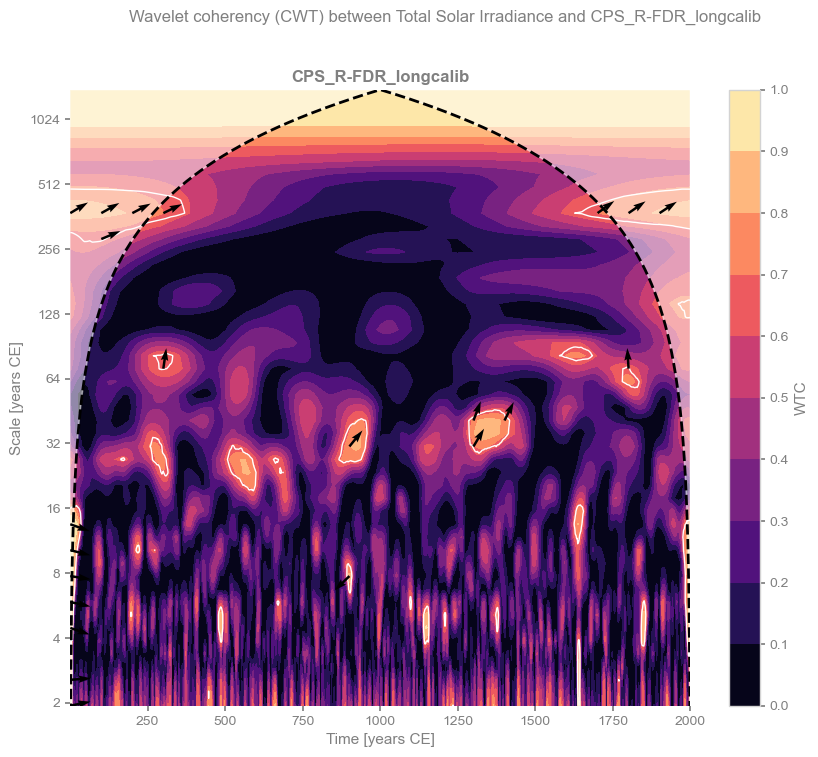

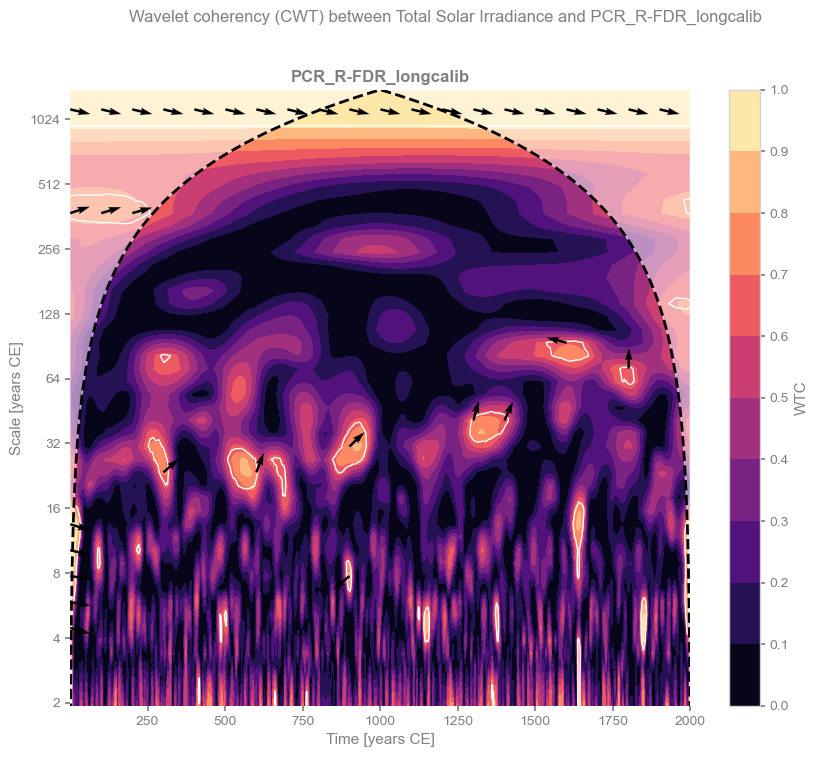

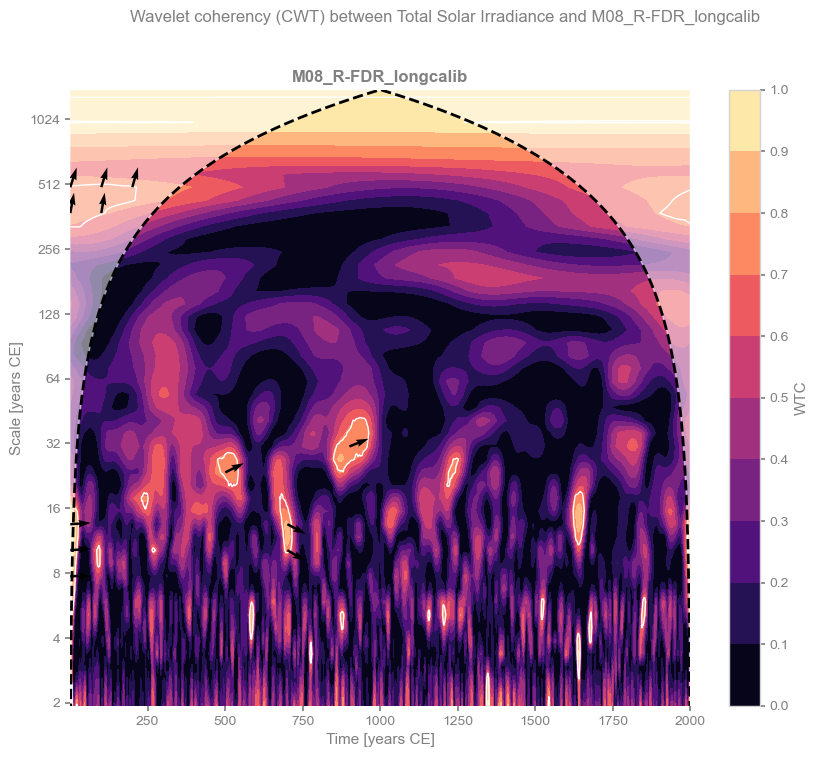

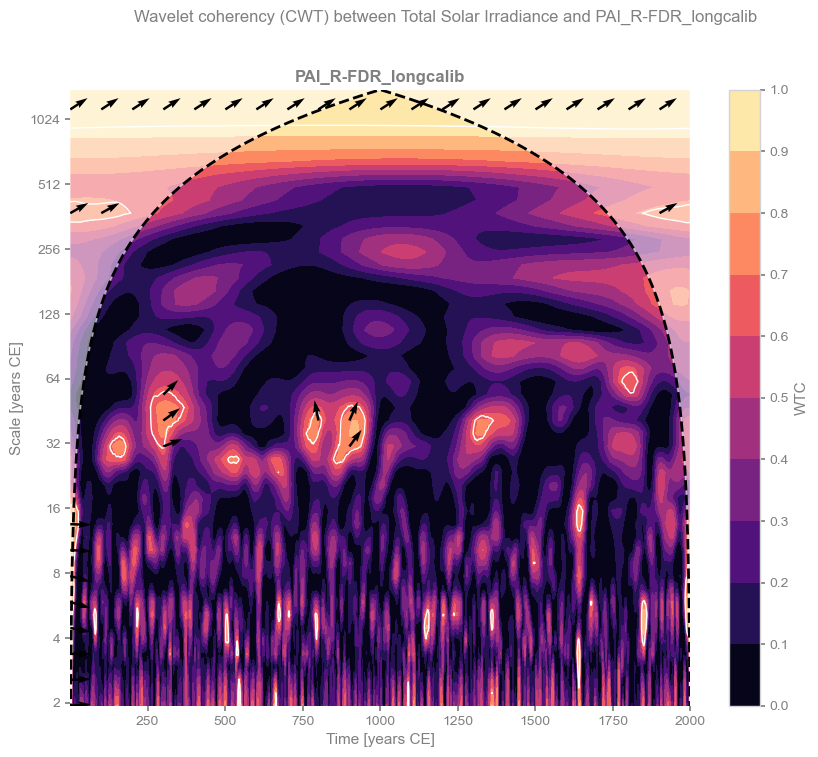

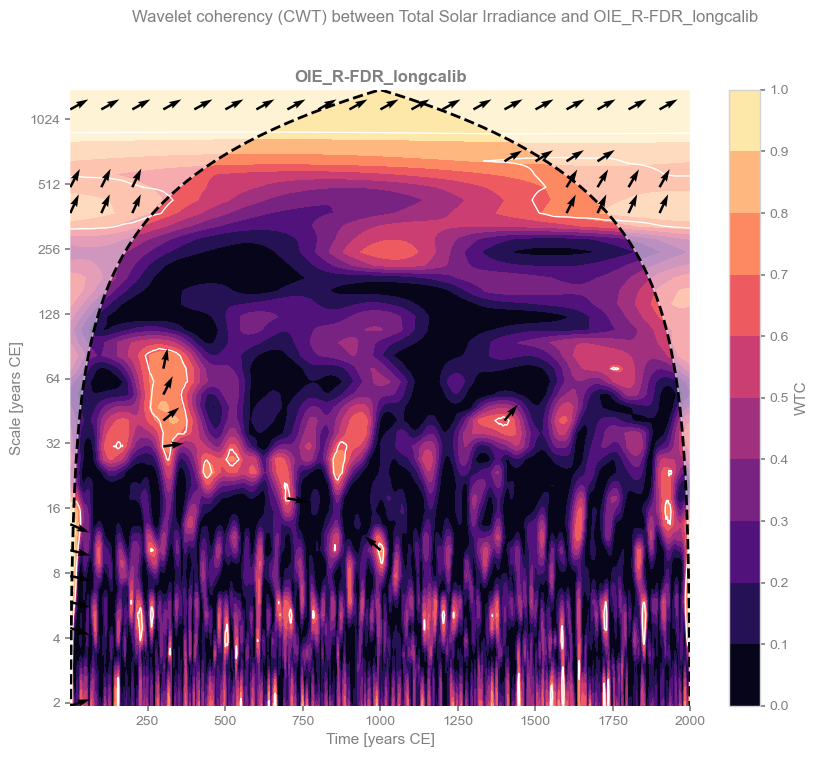

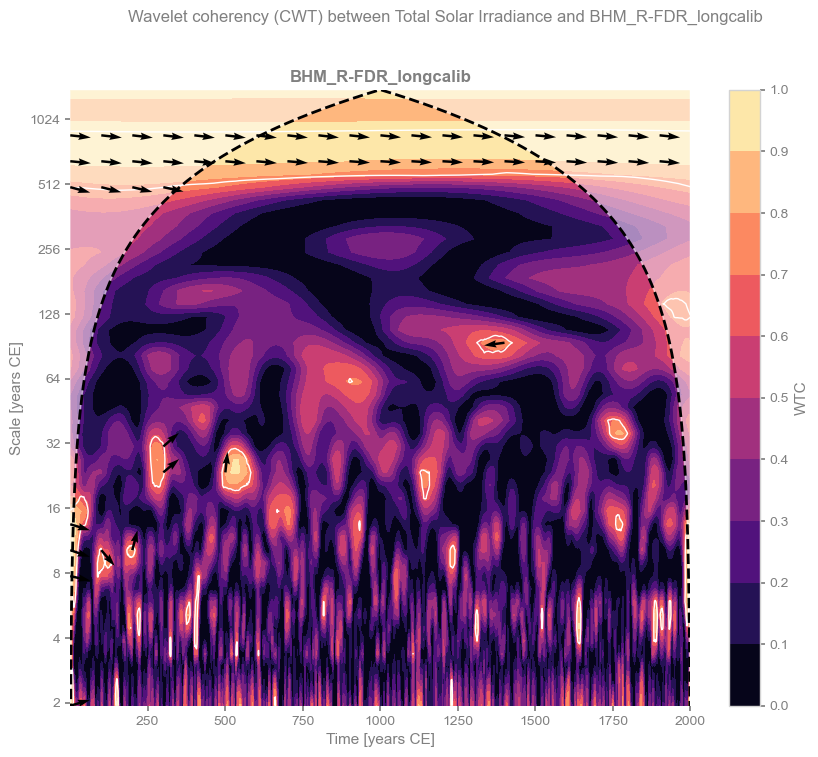

In [9]:
period_ticks = np.logspace(1, 11, num=11, base=2)
for exp in exp_names:
    fig, ax = coh[exp].plot(yticks=period_ticks)
    ax.set_title(exp, fontweight='bold')
    
pyleo.closefig()

We see very little coherence aside from isolated "islands" that rise above the red noise benchmark, with phase angles (arrows) darting in all directions, suggesting no robust phase relationship. In some cases, there is a hint of an in-phase relationship (high coherency and phase angles close to 0°) at periods longer than 500 years. However, this signal lies near the cone of influence (the region of the scalogram affected by edge effects) and does not appear significant when tested against a red-noise (AR(1)) benchmark. The main exception is the BHM reconstruction from [Barboza et al. (2019)](https://doi.org/10.1007/s13253-019-00372-4), which explicitly includes solar forcing as a predictor. It is therefore unsurprising that this reconstruction should exhibit coherence with solar variability, although the original study demonstrates that the signal is weak. 

## Phase Statistics

 To further quantify this, we can use Pyleoclim's [`phase_stats`](https://pyleoclim-util.readthedocs.io/en/latest/core/api.html#pyleoclim.core.coherences.Coherence.phase_stats) method, which characterizes the consistency of the phase relationship within a given scale band using two statistics from directional (circular) statistics:

- **σ (sigma)**: the circular standard deviation of the phase angles. A small σ indicates consistent phase angles across time; a large one suggests erratic phase behavior. Significance is assessed against an AR(1) null: if σ < σ_lo, the relationship is more phase-consistent than expected by chance.
- **κ (kappa)**: the concentration parameter of the Von Mises distribution — the circular analog of the normal distribution. Large κ means tightly clustered angles (strong phase lock). If κ > κ_hi, the phase relationship is significantly more concentrated than expected by chance.

We evaluate phase statistics over the centennial-to-millennial band (scales 100–2000 years), where solar forcing is thought to be most impactful.

In [10]:
rows = []
for exp in exp_names:
    ps = coh[exp].phase_stats(scales=[100, 2000], number=1000)
    rows.append({
        'Reconstruction'  : exp,
        'mean angle (°)'  : np.round(ps.mean_angle / np.pi * 180, 1),
        'σ'               : np.round(ps.sigma, 3),
        'σ_lo (5%)'       : np.round(ps.sigma_lo, 3),
        'σ < σ_lo?'       : ps.sigma < ps.sigma_lo,
        'κ'               : np.round(ps.kappa, 3),
        'κ_hi (95%)'      : np.round(ps.kappa_hi, 3),
        'κ > κ_hi?'       : ps.kappa > ps.kappa_hi,
    })

import pandas as pd
phase_df = pd.DataFrame(rows).set_index('Reconstruction')
phase_df

,mean angle (°),σ,σ_lo (5%),σ < σ_lo?,κ,κ_hi (95%),κ > κ_hi?
Reconstruction,,,,,,,
CPS_R-FDR_longcalib,11.5,0.117,0.012,False,73.969,6869.386,False
PCR_R-FDR_longcalib,5.6,0.222,0.216,False,20.844,22.035,False
M08_R-FDR_longcalib,48.6,0.229,0.087,False,19.578,131.465,False
PAI_R-FDR_longcalib,27.7,0.208,0.202,False,23.719,25.098,False
OIE_R-FDR_longcalib,32.9,0.092,0.011,False,118.948,7965.727,False
BHM_R-FDR_longcalib,3.0,0.282,0.032,False,13.081,973.215,False
LMR_R-FDR_longcalib,48.3,0.209,0.048,False,23.401,440.932,False


The table above summarizes phase angle statistics for each GMST reconstruction vs. solar irradiance over the 100–2000 year band. Columns to focus on:

- mean angle (°): the average phase lag; values near 0° indicate in-phase behavior (solar leads or lags by a small fraction of the period), values near ±180° indicate anti-phase.
- **$\sigma < \sigma_\mathrm{lo}$?** and **$\kappa > \kappa_\mathrm{hi}?$**: Boolean flags indicating whether the phase relationship is significantly more consistent than expected from a red-noise (AR(1)) null. Both flags must be `True` for the phase lock to be considered statistically significant.

Neither flag is satisfied for any reconstruction, confirming the absence of a robust, consistent phase lock between solar irradiance and GMST at centennial-to-millennial scales. Note, however, that spectral relationships are neither necessary not sufficient to establish causality. For a look at this question over a slightly longer timescale, the reader is referred to [Landers et al. (2025)](https://doi.org/10.22541/essoar.176598901.17168843/v1). 